# Linear Regression


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 3. Nonlinear

$$f(x) = \sin(3.2x) + 0.8x$$


### 3. 生成假資料

In [5]:
x = np.linspace(0, 5, 100)
y = np.sin(3.2*x) + 0.8*x + 0.3*np.random.randn(100)

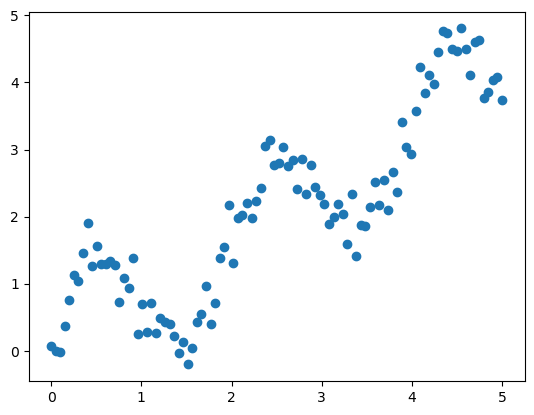

In [6]:
plt.scatter(x,y)

#### nonlinear

In [7]:
regr_lin = LinearRegression()

In [8]:
X = x.reshape(-1, 1)
print(X.shape)

(100, 1)


In [9]:
regr_lin.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


0.5019940918524567


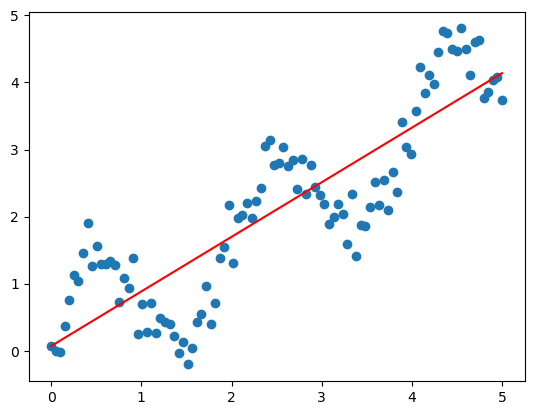

In [10]:
Y=regr_lin.predict(X)
plt.scatter(x,y)
plt.plot(x,Y , color='r')
mse = np.sum((Y-y)**2) / len(y)
print(mse)

果然超級不準, 該如何是好?

#### 多項式

多項式5次方

$$\widehat{y}=xw+b=w_{1}x_{1}+w_{2}x_{1}^{2}+w_{3}x_{1}^{3}+w_{4}x_{1}^{4}+w_{5}x_{1}^{5}+b$$

In [11]:
print(x.shape)

(100,)


In [13]:
X_poly = np.array([[k, k**2, k**3, k**4, k**5] for k in x])  # add k**6 to try it
print(X_poly.shape)

(100, 5)


In [14]:
regr_poly = LinearRegression()

In [15]:
regr_poly.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


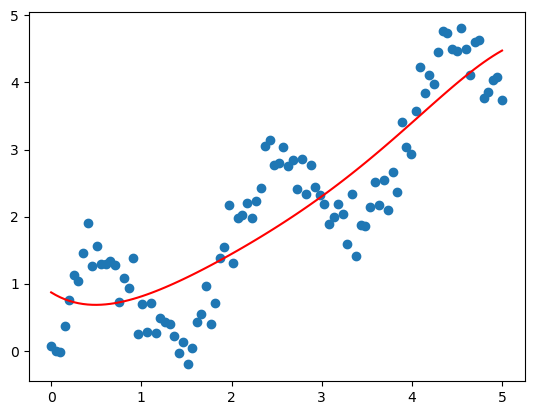

In [16]:
plt.scatter(x,y)
plt.plot(x, regr_poly.predict(X_poly), 'r')

In [17]:
print('Coefficients: ', regr_poly.coef_)
print('interception: ', regr_poly.intercept_)

Coefficients:  [-0.83725482  1.12214142 -0.42278094  0.084062   -0.00638578]
interception:  0.8718526086457665


In [19]:
W=regr_poly.coef_
b=regr_poly.intercept_
np.dot(X_poly,W.T)+b

array([0.87185261, 0.8323754 , 0.79830363, 0.76932987, 0.74515933,
       0.72550958, 0.71011033, 0.69870313, 0.69104118, 0.686889  ,
       0.68602226, 0.68822747, 0.69330176, 0.7010526 , 0.7112976 ,
       0.72386417, 0.73858937, 0.75531958, 0.77391029, 0.79422584,
       0.81613914, 0.83953148, 0.8642922 , 0.89031852, 0.9175152 ,
       0.94579438, 0.97507526, 1.00528386, 1.03635281, 1.06822104,
       1.10083358, 1.13414126, 1.16810051, 1.20267304, 1.23782567,
       1.27353002, 1.30976227, 1.34650292, 1.38373653, 1.42145147,
       1.45963967, 1.49829636, 1.53741982, 1.57701115, 1.61707399,
       1.65761428, 1.69864   , 1.74016093, 1.78218841, 1.82473504,
       1.86781448, 1.91144118, 1.95563012, 2.00039655, 2.04575579,
       2.0917229 , 2.1383125 , 2.18553846, 2.2334137 , 2.2819499 ,
       2.33115726, 2.38104426, 2.43161738, 2.4828809 , 2.53483657,
       2.58748345, 2.64081756, 2.69483172, 2.74951524, 2.80485369,
       2.86082864, 2.91741742, 2.97459284, 3.03232297, 3.09057

In [20]:
regr_poly.predict(X_poly)

array([0.87185261, 0.8323754 , 0.79830363, 0.76932987, 0.74515933,
       0.72550958, 0.71011033, 0.69870313, 0.69104118, 0.686889  ,
       0.68602226, 0.68822747, 0.69330176, 0.7010526 , 0.7112976 ,
       0.72386417, 0.73858937, 0.75531958, 0.77391029, 0.79422584,
       0.81613914, 0.83953148, 0.8642922 , 0.89031852, 0.9175152 ,
       0.94579438, 0.97507526, 1.00528386, 1.03635281, 1.06822104,
       1.10083358, 1.13414126, 1.16810051, 1.20267304, 1.23782567,
       1.27353002, 1.30976227, 1.34650292, 1.38373653, 1.42145147,
       1.45963967, 1.49829636, 1.53741982, 1.57701115, 1.61707399,
       1.65761428, 1.69864   , 1.74016093, 1.78218841, 1.82473504,
       1.86781448, 1.91144118, 1.95563012, 2.00039655, 2.04575579,
       2.0917229 , 2.1383125 , 2.18553846, 2.2334137 , 2.2819499 ,
       2.33115726, 2.38104426, 2.43161738, 2.4828809 , 2.53483657,
       2.58748345, 2.64081756, 2.69483172, 2.74951524, 2.80485369,
       2.86082864, 2.91741742, 2.97459284, 3.03232297, 3.09057

#### RBF

$$\phi_i = e^{-\| x - c_i \|^2/2\sigma^2}$$

In [21]:
# normal distrubution
def RBF(x, center, sigma):
    k = np.exp(-(x - center)**2/(2*sigma**2))
    return k

In [22]:
sigma = 0.3

In [24]:
X_rbf = np.array([[RBF(k, .5, sigma), 
                  RBF(k, 1.5, sigma),
                  RBF(k, 2.5, sigma),
                  RBF(k, 3.5, sigma),
                  RBF(k, 4.5, sigma)] for k in x])



In [25]:
regr_rbf = LinearRegression()

In [26]:
regr_rbf.fit(X_rbf, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


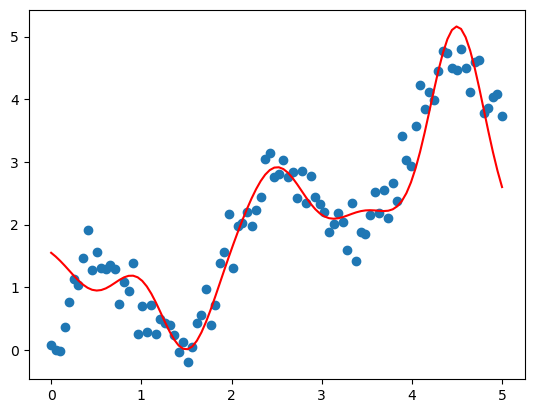

In [27]:
plt.scatter(x,y)
plt.plot(x, regr_rbf.predict(X_rbf), 'r')

In [28]:
print('Coefficients: ', regr_rbf.coef_)
print('interception: ', regr_rbf.intercept_)

Coefficients:  [-0.7940568  -1.74220869  1.17376711  0.46245699  3.41334662]
interception:  1.7469212821322855


#### Comparison

In [29]:
Y_lin = regr_lin.predict(X)
Y_poly = regr_poly.predict(X_poly)
Y_rbf = regr_rbf.predict(X_rbf)

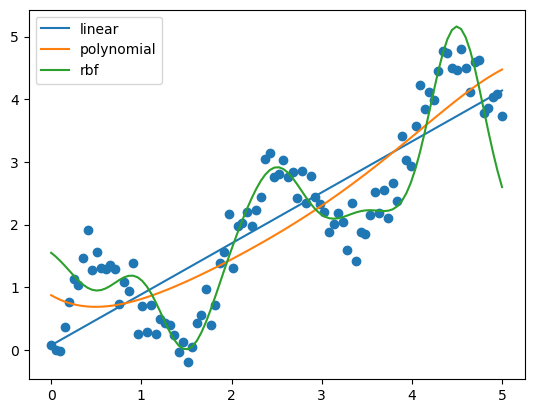

In [30]:
plt.scatter(x,y)

plt.plot(x, Y_lin, label='linear')
plt.plot(x, Y_poly, label='polynomial')
plt.plot(x, Y_rbf, label='rbf')
plt.legend()

## 請計算模型的MSE

In [31]:
print(np.sum((regr_lin.predict(X)-y)**2) / len(y))

0.5019940918524567


In [32]:
print(np.sum((regr_poly.predict(X_poly)-y)**2) / len(y))

0.4369266251616785


In [33]:
print(np.sum((regr_rbf.predict(X_rbf)-y)**2) / len(y))

0.24594134974412685
